In [3]:
import os
from dotenv import load_dotenv
ROOT = "../" # Base directory relative to this notebook's location. Adjust if the notebook is moved
CSV_DIR = os.path.join(ROOT, "csv")
DOTENV_PATH = os.path.join(ROOT, '../../apis/.env') # Adjust to .env file location
if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    drive, rel = os.path.splitdrive(abs_path)
    parts = rel.strip(os.sep).split(os.sep)
    masked = parts.copy()
    masked_parts = 1  # adjust to mask parts of your path
    max_maskable = max(0, len(parts) - 2)
    for i in range(min(masked_parts, max_maskable)):
        idx = len(parts) - 3 - i
        masked[idx] = "***"
    prefix = f"{drive}{os.sep}" if drive else (os.sep if abs_path.startswith(os.sep) else "")
    print(f"Loaded .env from {prefix}{os.sep.join(masked)}")
else:
    print("Failed to load .env file.")

API_KEY = os.getenv("AEMET_API_KEY")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"AEMET_API_KEY: {mask_token(API_KEY)}")

# Variables de ejecución avanzadas (no es necesario cambiarlas si no se ha alterado la estructura de ficheros del proyecto):
DB_FILE = "db/thematic_screener.db" # Sólo necesario si DOWNLOAD_REMOTE_DB = False
import sys
sys.path.append(ROOT)

from src.aemet_helpers import AemetClient
from src.weather_data_download import download_station_data
import random
from datetime import datetime
import pandas as pd
import json
import time
import matplotlib.pyplot as plt

Loaded .env from c:\Users\david\***\apis\.env
AEMET_API_KEY: eyJ***********************************************************************************************************************************************************************************************************************************************************************************************************rF4


### Exploring station codes

In [9]:
json_path = os.path.join(ROOT, "json", "locations.json")
with open(json_path, "r", encoding="utf-8") as f:
    locations_df = pd.DataFrame(
        list(json.load(f).items()),
        columns=["code", "location"]
    )

display(locations_df.sample(5))

,code,location
119,1442U,BOIRO
742,C029O,LANZAROTE/AEROPUERTO
399,5470,FUENTE PALMERA-LOS ARROYONES
412,5641X,ECIJA
634,9436X,FONFRÍA


### Querying up to 6 months

In [17]:
client = AemetClient(API_KEY)
station_id = "1442U"
start_date = "2024-01-01"
n_dias = 180  # each query supports approximately 6 months of data
end_date = (datetime.strptime(start_date, "%Y-%m-%d") + pd.Timedelta(days=n_dias)).strftime("%Y-%m-%d")
data = pd.DataFrame(client.fetch_station_history(station_id, start_date, end_date))
display(data.head(5))
print("...")
display(data.tail(5))
last_date = pd.to_datetime(data['fecha']).iloc[-1]
print(last_date)

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2024-01-01,1442U,BOIRO,A CORUÑA,10,"9,6","2,6","5,7",00:16,"13,6",16:08,88,98,09:00,77,16:00
1,2024-01-02,1442U,BOIRO,A CORUÑA,10,"14,2","30,6","13,2",00:08,"15,1",14:06,92,96,Varias,84,Varias
2,2024-01-03,1442U,BOIRO,A CORUÑA,10,"12,0","2,0","9,1",21:34,"14,8",15:05,85,96,22:20,78,09:50
3,2024-01-04,1442U,BOIRO,A CORUÑA,10,"10,5","12,8","6,7",22:43,"14,3",10:17,88,93,Varias,69,15:00
4,2024-01-05,1442U,BOIRO,A CORUÑA,10,"7,6","1,8","3,7",23:59,"11,5",12:35,91,98,09:30,78,16:30


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
176,2024-06-25,1442U,BOIRO,A CORUÑA,10,"18,2","0,2","16,6",06:08,"19,9",00:01,88,94,08:20,81,13:30
177,2024-06-26,1442U,BOIRO,A CORUÑA,10,"20,8","0,0","16,8",04:18,"24,8",14:15,79,94,Varias,65,14:20
178,2024-06-27,1442U,BOIRO,A CORUÑA,10,"23,1","0,0","18,1",04:31,"28,1",12:10,69,82,04:40,57,11:50
179,2024-06-28,1442U,BOIRO,A CORUÑA,10,"22,6","0,0","17,6",05:04,"27,5",14:35,65,78,01:40,55,13:10
180,2024-06-29,1442U,BOIRO,A CORUÑA,10,"21,2","5,8","16,5",04:08,"26,0",12:52,63,93,Varias,51,13:00


2024-06-29 00:00:00


### Retrieving 6+ months of historical data

In [26]:
sample_idema = "1442U"
df = download_station_data(client, station_id=sample_idema, start_date="2021-01-01", max_retries=5, sleep_seconds=6)

Fetching data for station 1442U from 2021-01-01 to 2021-06-30...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-01-01T00:00:00UTC/fechafin/2021-06-30T00:00:00UTC/estacion/1442U (Retry 1/5)
Fetching data for station 1442U from 2021-01-01 to 2021-06-30...
✓ Retrieved 180 records (from 2021-01-01 to 2021-06-30)
Fetching data for station 1442U from 2021-07-01 to 2021-12-28...
✓ Retrieved 181 records (from 2021-07-01 to 2021-12-28)
Fetching data for station 1442U from 2021-12-29 to 2022-06-27...
✓ Retrieved 181 records (from 2021-12-29 to 2022-06-27)
Fetching data for station 1442U from 2022-06-28 to 2022-12-25...
✓ Retrieved 181 records (from 2022-06-28 to 2022-12-25)
Fetching data for station 1442U from 2022-12-26 to 2023-06-24...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2022-12-26T00:00:00UTC/fec

In [27]:
display(df.head(3))
print("...")
display(df.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2021-01-01,1442U,BOIRO,A CORUÑA,10,"5,9","7,0","2,1",08:46,"9,7",14:38,93,98,10:00,82,15:30
1,2021-01-02,1442U,BOIRO,A CORUÑA,10,"5,6","0,2","2,0",23:40,"9,3",15:43,94,97,Varias,84,15:50
2,2021-01-03,1442U,BOIRO,A CORUÑA,10,"5,0","0,0","0,9",06:40,"9,0",15:59,95,99,08:20,91,16:30


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
1944,2026-04-30,1442U,BOIRO,A CORUÑA,10,"16,0","0,0","10,8",06:15,"21,1",14:31,75,89,06:40,61,12:40
1945,2026-05-01,1442U,BOIRO,A CORUÑA,10,"15,7","0,8","9,7",04:44,"21,7",13:04,72,95,05:00,45,16:50
1946,2026-05-02,1442U,BOIRO,A CORUÑA,10,"15,2","3,8","11,0",04:04,"19,4",13:04,83,94,Varias,70,13:10


### Casting column formats

In [28]:
df.columns
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: object
indicativo: object
nombre: object
provincia: object
altitud: object
tmed: object
prec: object
tmin: object
horatmin: object
tmax: object
horatmax: object
hrMedia: object
hrMax: object
horaHrMax: object
hrMin: object
horaHrMin: object


In [29]:
date_cols = ["fecha"]
text_cols = ["indicativo", "nombre", "provincia"]
int_cols = ["altitud", "dir", "hrMedia", "hrMax", "hrMin"]
float_cols = ["tmed", "prec", "tmin", "tmax", "velmedia", "racha", "sol", "presMax", "presMin"]
time_cols = ["horatmin", "horatmax", "horaracha", "horaPresMax", "horaPresMin", "horaHrMax", "horaHrMin"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format="%Y-%m-%d", errors="coerce")

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

for col in int_cols:
    if col in df.columns:
        df[col] = (
            pd.to_numeric(df[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")
            .astype("Int64")
        )

for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")

for col in time_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

In [30]:
df.columns
print("\nColumn types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")


Column types:
fecha: datetime64[ns]
indicativo: string
nombre: string
provincia: string
altitud: Int64
tmed: Float64
prec: Float64
tmin: Float64
horatmin: string
tmax: Float64
horatmax: string
hrMedia: Int64
hrMax: Int64
horaHrMax: string
hrMin: Int64
horaHrMin: string


In [31]:
df.to_csv(os.path.join(CSV_DIR,f"hist_{sample_idema}_from_2021.csv"), index=False)

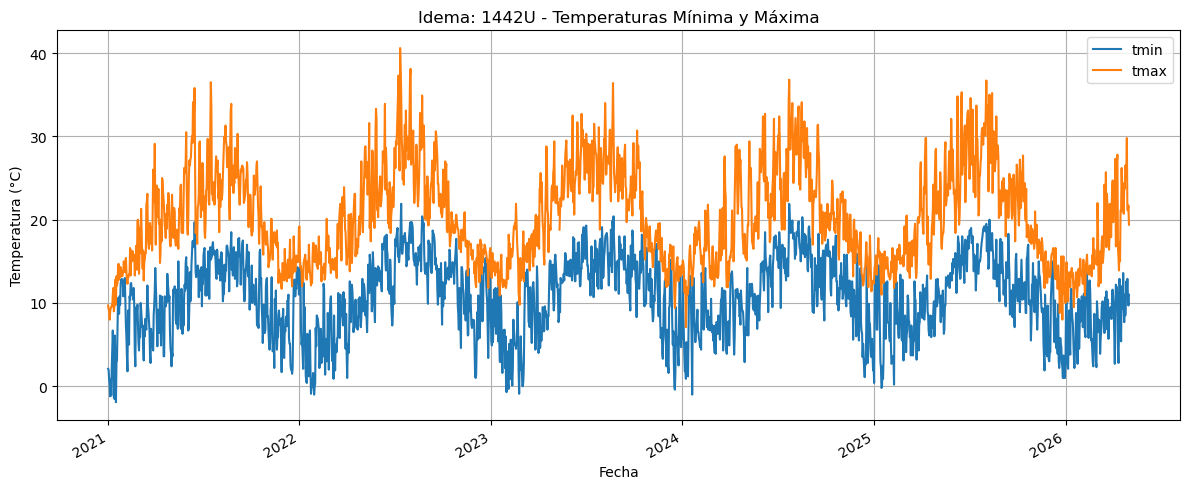

In [32]:
ax = df.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Idema: {sample_idema} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

### Testing a second location

In [34]:
display(locations_df.sample(3))

,code,location
138,1542,PUERTO DE LEITARIEGOS
295,3516X,PIORNAL (AUTOMATICA)
542,8198Y,ALMANSA


In [35]:
sample_idema = "1542"
df_sample = download_station_data(client, station_id=sample_idema, start_date="2021-01-01", max_retries=5, sleep_seconds=6)

Fetching data for station 1542 from 2021-01-01 to 2021-06-30...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-01-01T00:00:00UTC/fechafin/2021-06-30T00:00:00UTC/estacion/1542 (Retry 1/5)
Fetching data for station 1542 from 2021-01-01 to 2021-06-30...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-01-01T00:00:00UTC/fechafin/2021-06-30T00:00:00UTC/estacion/1542 (Retry 2/5)
Fetching data for station 1542 from 2021-01-01 to 2021-06-30...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos/fechaini/2021-01-01T00:00:00UTC/fechafin/2021-06-30T00:00:00UTC/estacion/1542 (Retry 3/5)
Fetching data for station 1542 from 2021-01-01 to 2021-06-30...
✗ Error: 429 Client Error: Too Many Requests for url: https://opendata.aemet.es/open

In [36]:
display(df_sample.head(3))
print("...")
display(df_sample.tail(3))

,fecha,indicativo,nombre,provincia,altitud,tmed,tmin,horatmin,tmax,horatmax,...,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,velmedia,dir,racha,horaracha,prec
0,2021-01-01,1542,PUERTO DE LEITARIEGOS,ASTURIAS,1530,"-4,0","-5,6",22:00,"-2,4",11:20,...,94,94,Varias,92,13:40,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,1542,PUERTO DE LEITARIEGOS,ASTURIAS,1530,"-3,8","-5,8",08:00,"-1,9",13:00,...,93,94,Varias,92,Varias,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,1542,PUERTO DE LEITARIEGOS,ASTURIAS,1530,"-3,1","-4,8",23:59,"-1,4",12:00,...,94,94,Varias,93,Varias,NaN,NaN,NaN,NaN,NaN


...


,fecha,indicativo,nombre,provincia,altitud,tmed,tmin,horatmin,tmax,horatmax,...,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,velmedia,dir,racha,horaracha,prec
1883,2026-04-25,1542,PUERTO DE LEITARIEGOS,ASTURIAS,1530,"9,2","4,0",05:20,"14,4",14:20,...,86,100,Varias,52,09:50,"3,3",32,"10,0",14:30,NaN
1884,2026-05-01,1542,PUERTO DE LEITARIEGOS,ASTURIAS,1530,"9,4","4,8",04:20,"14,1",14:30,...,82,100,Varias,49,14:00,"2,8",14,"8,9",11:10,"0,0"
1885,2026-05-02,1542,PUERTO DE LEITARIEGOS,ASTURIAS,1530,"9,0","4,9",23:59,"13,2",12:00,...,83,100,22:20,47,12:10,"3,6",16,"13,9",09:50,"2,0"


In [39]:
date_cols = ["fecha"]
text_cols = ["indicativo", "nombre", "provincia"]
int_cols = ["altitud", "dir", "hrMedia", "hrMax", "hrMin"]
float_cols = ["tmed", "prec", "tmin", "tmax", "velmedia", "racha", "sol", "presMax", "presMin"]
time_cols = ["horatmin", "horatmax", "horaracha", "horaPresMax", "horaPresMin", "horaHrMax", "horaHrMin"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format="%Y-%m-%d", errors="coerce")

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

for col in int_cols:
    if col in df.columns:
        df[col] = (
            pd.to_numeric(df[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")
            .astype("Int64")
        )

for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")

for col in time_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

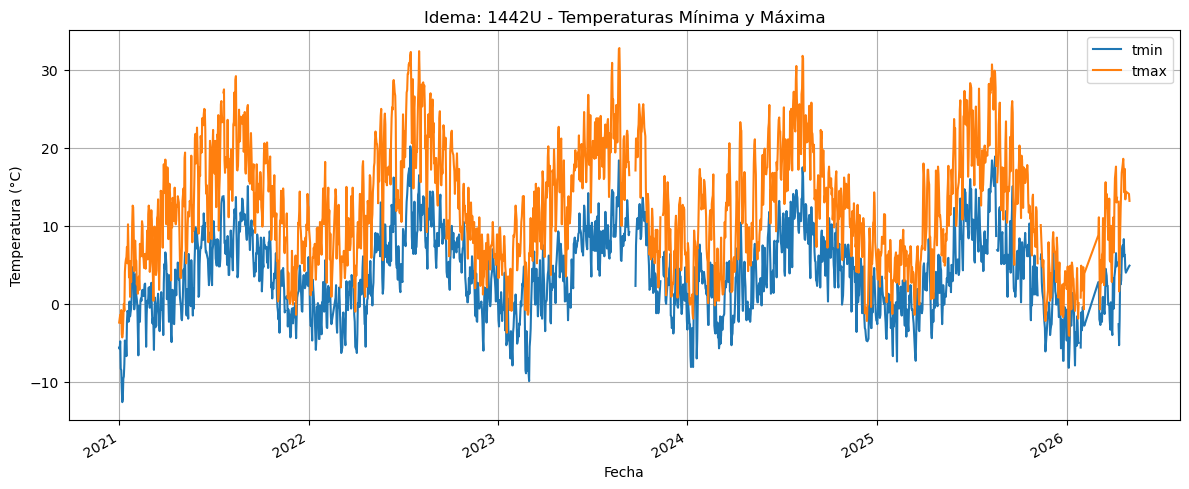

In [40]:
ax = df_sample.sort_values("fecha").plot(x="fecha", y=["tmin", "tmax"], kind="line", figsize=(12,5))
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Idema: {station_id} - Temperaturas Mínima y Máxima")
ax.grid(True)
plt.tight_layout()
plt.show()

In [42]:
df_sample.to_csv(os.path.join(CSV_DIR,f"hist_{sample_idema}_from_2021.csv"), index=False)